# Prepare data

## read dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('USDCAD_H4.csv', sep='\t')

df

,Time,Open,High,Low,Close,Volume
0,2008-02-14 16:00:00,0.99800,0.99985,0.99720,0.99980,8162
1,2008-02-14 20:00:00,0.99980,1.00070,0.99830,1.00015,12631
2,2008-02-15 00:00:00,1.00015,1.00020,0.99905,0.99950,4417
3,2008-02-15 04:00:00,0.99950,0.99990,0.99705,0.99720,5803
4,2008-02-15 08:00:00,0.99720,0.99890,0.99195,0.99585,12635
...,...,...,...,...,...,...
25842,2024-02-23 04:00:00,1.34821,1.34824,1.34752,1.34765,8255
25843,2024-02-23 08:00:00,1.34765,1.35017,1.34718,1.34791,19740
25844,2024-02-23 12:00:00,1.34791,1.35037,1.34611,1.35013,28386
25845,2024-02-23 16:00:00,1.35013,1.35171,1.34904,1.35002,20316


In [ ]:
[[ ... 1.3502e+00, -1.1000e-04,  2.2200e-03,  2.6000e-04, -5.5000e-04, 2.6000e-04, -5.5000e-04, -5.0000e-05, -5.8000e-04, -1.1200e-03, -5.8000e-04, -1.1200e-03 ...  ,  4.6700e-03, -1.0000e-04, -3.2700e-03],
 ...,
 [-4.0000e-04, -6.0000e-04,  2.5000e-03, -1.9500e-03, -9.0000e-04],
 [-1.9500e-03, -9.0000e-04,  2.4100e-03, -3.1600e-03,  6.8000e-03],
 [-3.1600e-03,  6.8000e-03,  6.4500e-03, -1.3500e-03, -2.3000e-03]]

In [2]:
data = df['Close'].to_numpy()
data = data[::-1]  # last candle (newest) should be at index 0

data

array([1.3502 , 1.35002, 1.35013, ..., 0.9995 , 1.00015, 0.9998 ])

## record difference between consecutive points

In [4]:
ddata = np.roll(data, -1)
base_value = data[0]

ddata[0] = 0
ddata = data - ddata

ddata

array([ 1.3502e+00, -1.1000e-04,  2.2200e-03, ..., -6.5000e-04,
        3.5000e-04, -3.5040e-01])

## quantize the sequence

In [16]:
q = 3  # quantization length
sq = 1  # shadow length

def quantize(candles, q, sq):
  n, =candles.shape
  Q = []
  for i in range(sq, n, q):
    if i+q+sq >= n: break
    vec = candles[i-sq:i+q+sq]
    Q.append(vec)
  return np.array(Q)

Q = quantize(ddata, q, sq)
Q, Q.shape

(array([[ 1.3502e+00, -1.1000e-04,  2.2200e-03,  2.6000e-04, -5.5000e-04],
        [ 2.6000e-04, -5.5000e-04, -5.0000e-05, -5.8000e-04, -1.1200e-03],
        [-5.8000e-04, -1.1200e-03,  4.6700e-03, -1.0000e-04, -3.2700e-03],
        ...,
        [-4.0000e-04, -6.0000e-04,  2.5000e-03, -1.9500e-03, -9.0000e-04],
        [-1.9500e-03, -9.0000e-04,  2.4100e-03, -3.1600e-03,  6.8000e-03],
        [-3.1600e-03,  6.8000e-03,  6.4500e-03, -1.3500e-03, -2.3000e-03]]),
 (8614, 5))

## generate language tokens by clustering

### Deciding How Many Clusters to Build

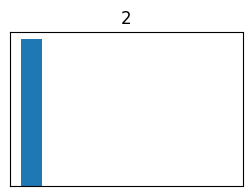

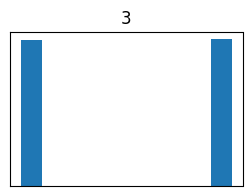

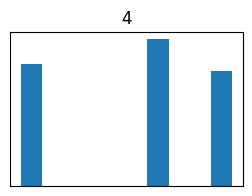

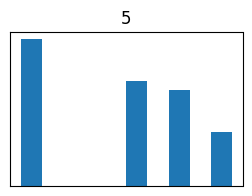

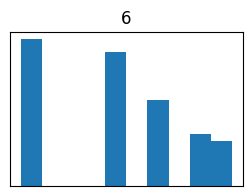

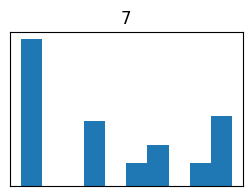

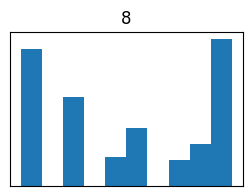

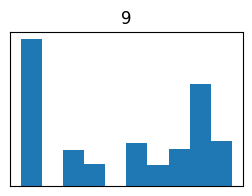

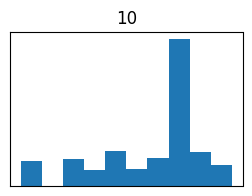

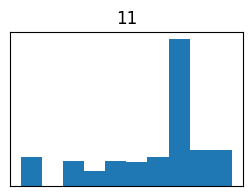

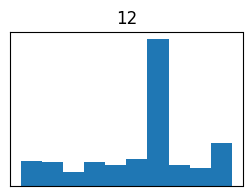

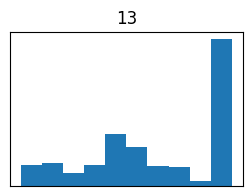

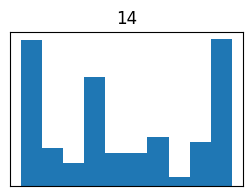

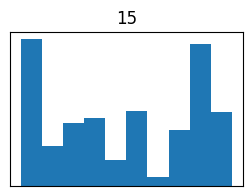

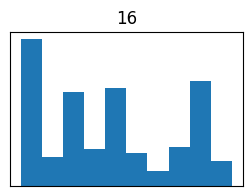

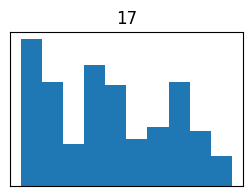

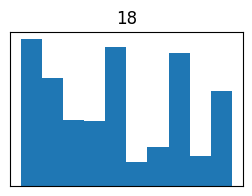

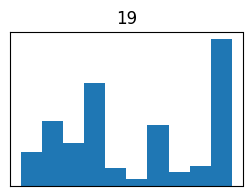

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

for i in range(2, 20):
  kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto")
  kmeans.fit(Q)
  plt.figure(figsize=(3,2))
  plt.hist(kmeans.labels_)
  plt.title(f'{i}')
  plt.xticks([]), plt.yticks([])
  plt.show()

### apply clustring

In [7]:
from sklearn.cluster import KMeans

n_cluster = 18

kmeans = KMeans(n_clusters=n_cluster, random_state=0, n_init="auto")
kmeans.fit(Q)

KMeans(n_clusters=18, n_init='auto', random_state=0)

### check the performance of clustring

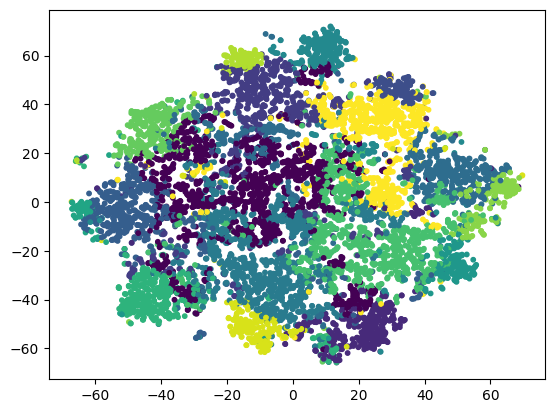

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2,
            perplexity=50,
            learning_rate='auto',
            init='pca',
            random_state = 0)
Q_2d = tsne.fit_transform(Q)

plt.scatter(Q_2d[:, 0], Q_2d[:, 1], s=10, c=kmeans.labels_)
plt.show()

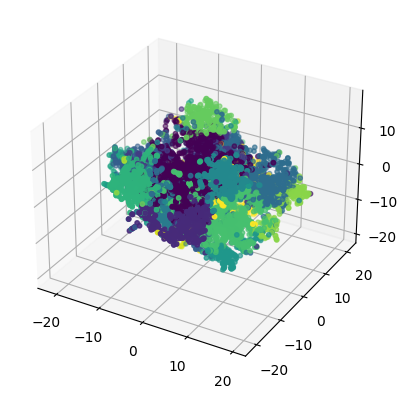

In [ ]:
tsne = TSNE(n_components=3,
            perplexity=50,
            learning_rate='auto',
            init='pca',
            random_state = 0)
Q_3d = tsne.fit_transform(Q)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(Q_3d[:, 0], Q_3d[:, 1], Q_3d[:, 2], s=10, c=kmeans.labels_)
plt.show()

### plot tokens

In [17]:
def get_candles(cluster_id):
  input = kmeans.cluster_centers_[cluster_id].copy()[::-1]
  closes = input
  opens = np.roll(closes, 1)
  opens[0] = closes[0]
  return pd.DataFrame({'opens':opens, 'closes':closes})

factors = [get_candles(i) for i in range(n_cluster)]

In [25]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=18, subplot_titles=[f'Token_{i}' for i in range(18)])

for i in range(18):
  fig.add_trace(
    go.Candlestick(
      open = factors[i].opens,
      high = factors[i].opens,
      low = factors[i].closes,
      close = factors[i].closes
    ),
    row=1, col=i+1
  )

fig.update_layout(width = 5000, height = 400)
fig.show()

## generate samples (sentences)

In [ ]:
['USDCAD_1',
 'USDCAD_0',
 'USDCAD_7',
 ...,
 'USDCAD_7',
 'USDCAD_4',
 'USDCAD_13']

In [13]:
labels = kmeans.labels_.astype(object)

for cluster_id in range(n_cluster):
  labels[labels == cluster_id] = f'USDCAD_{cluster_id}'

labels

array(['USDCAD_1', 'USDCAD_0', 'USDCAD_7', ..., 'USDCAD_7', 'USDCAD_4',
       'USDCAD_13'], dtype=object)

In [26]:
w = 5  # window size (number of tokens in a sample)

def generage_samples(labels, w, n):
  X, y = [], []
  i = 0
  while i + w + 1 < n:
    y.append(labels[i])
    X.append(np.flip(labels[i+1 : i+1+w]).copy()) # reverse to have last token at end
    i += (w+1)
  return pd.DataFrame({'X':X, 'y':y})

samples = generage_samples(labels, w, Q.shape[0])
samples

,X,y
0,"[USDCAD_0, USDCAD_12, USDCAD_12, USDCAD_7, USD...",USDCAD_1
1,"[USDCAD_0, USDCAD_7, USDCAD_7, USDCAD_7, USDCA...",USDCAD_3
2,"[USDCAD_14, USDCAD_2, USDCAD_12, USDCAD_12, US...",USDCAD_3
3,"[USDCAD_7, USDCAD_0, USDCAD_0, USDCAD_0, USDCA...",USDCAD_3
4,"[USDCAD_13, USDCAD_17, USDCAD_5, USDCAD_3, USD...",USDCAD_12
...,...,...
1430,"[USDCAD_11, USDCAD_0, USDCAD_5, USDCAD_16, USD...",USDCAD_13
1431,"[USDCAD_17, USDCAD_16, USDCAD_5, USDCAD_16, US...",USDCAD_12
1432,"[USDCAD_0, USDCAD_17, USDCAD_5, USDCAD_3, USDC...",USDCAD_17
1433,"[USDCAD_6, USDCAD_17, USDCAD_5, USDCAD_15, USD...",USDCAD_8


# save all information

In [31]:
import pickle

info = {
    'org_signal' : 'USDCAD',
    'signal_period' : '4H',
    'q_length' : q,
    'q_shadow_length' : sq,
    'window_length' : w,

    'vocabulary' : list(np.unique(labels)),
    'token_representatives' : factors,
    'samples' : samples
}

with open('USDCAD.info.pkl', 'wb') as f:
    pickle.dump(info, f)

In [32]:
loaded_dict = None

with open('USDCAD.info.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

for k, v in loaded_dict.items():
  print(f'{k} : {type(v)}')

org_signal : <class 'str'>
signal_period : <class 'str'>
q_length : <class 'int'>
q_shadow_length : <class 'int'>
window_length : <class 'int'>
vocabulary : <class 'list'>
token_representatives : <class 'list'>
samples : <class 'pandas.core.frame.DataFrame'>
